In [1]:
pip install gdown

Note: you may need to restart the kernel to use updated packages.


In [2]:
!gdown 1RRbLfbAPiihXP50KDQQc6Cr52-r0fsoF

Using cookies from /Users/siddharth/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1RRbLfbAPiihXP50KDQQc6Cr52-r0fsoF
To: /Users/siddharth/Documents/Siddharth/MyNotes/MyNotes/AI_ML/Jupyter_Notebooks/train-cars24-car-price.csv
100%|█████████████████████████████████████| 1.25M/1.25M [00:00<00:00, 3.20MB/s]


In [3]:
import pandas as pd

In [7]:
data = pd.read_csv('train-cars24-car-price.csv')

In [8]:
data.head()

,full_name,selling_price,year,seller_type,km_driven,fuel_type,transmission_type,mileage,engine,max_power,seats
0,Maruti SX4 Zxi BSIII,2.85,2007.0,Individual,110000,Petrol,Manual,15.00,1586.0,104.68,5.0
1,Hyundai i20 Sportz 1.4 CRDi,4.70,2012.0,Dealer,70000,Diesel,Manual,21.90,1396.0,88.76,5.0
2,Maruti Swift VDI BSIV,5.25,2015.0,Individual,70000,Diesel,Manual,25.20,1248.0,74.00,5.0
3,Honda City 1.3 EXI,1.25,2005.0,Individual,90000,Petrol,Manual,13.00,1343.0,90.00,5.0
4,Volkswagen Polo 1.2 MPI Comfortline,4.65,2015.0,Dealer,41000,Petrol,Manual,16.47,1198.0,74.00,5.0


### **As an ML Engineer I have decided to select max_power who will decide the price of Cars, So first I have to visualize how max_power is moving with respect to price**

<Axes: title={'center': 'MaxPower vs. Price'}, xlabel='max_power', ylabel='selling_price'>

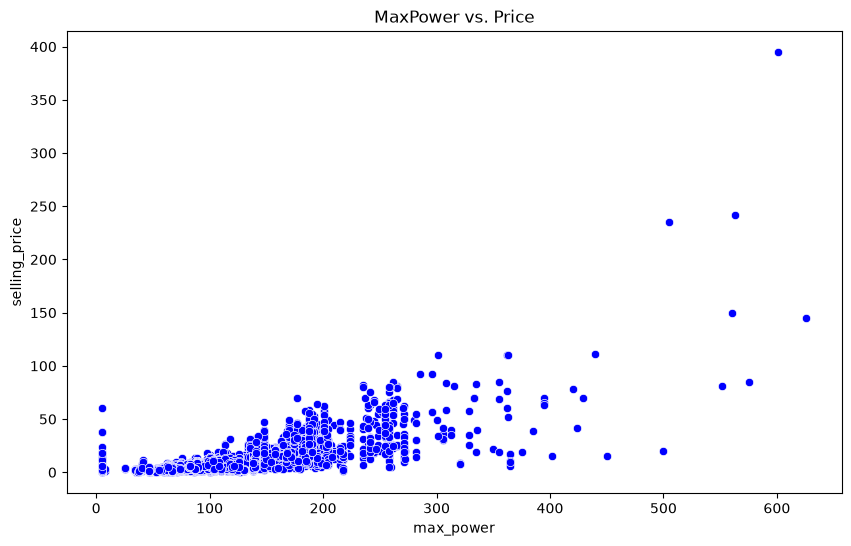

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.title('MaxPower vs. Price')

sns.scatterplot(data=data, x='max_power', y='selling_price', color='blue')

In [12]:
def get_prdicted_price(max_power, weight, bias):
    return weight * max_power + bias

In [ ]:
w = 50
b = 100

maxPower = data.max_power

predicted_Price = get_prdicted_price(maxPower, w, b)

print(predicted_Price)

0        5334.0
1        4538.0
2        3800.0
3        4600.0
4        3800.0
          ...  
13981    5260.0
13982    4200.0
13983    4257.0
13984    3250.0
13985    4257.0
Name: max_power, Length: 13986, dtype: float64


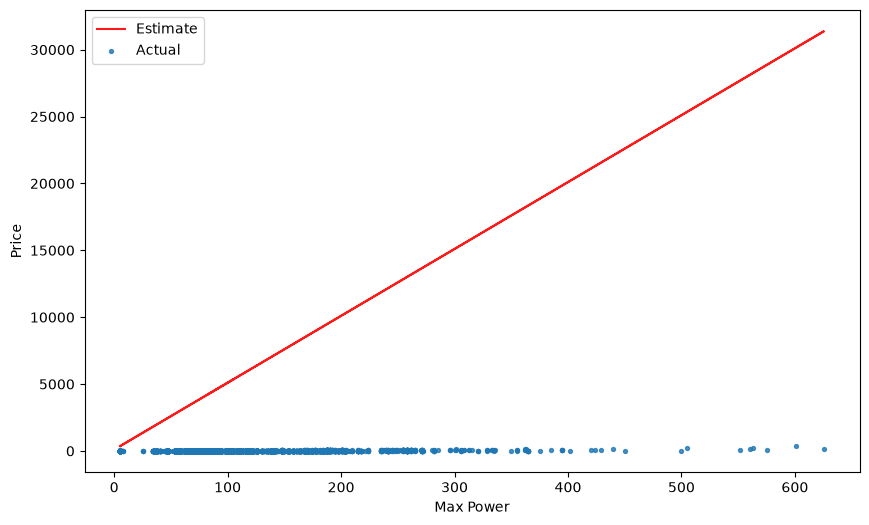

In [20]:
target = data.selling_price

plt.figure(figsize=(10, 6))
plt.plot(maxPower, predicted_Price, color='red', alpha=0.9);
plt.scatter(maxPower, target, s=8, alpha=0.8);
plt.xlabel('Max Power')
plt.ylabel('Price')
plt.legend(['Estimate', 'Actual']);
plt.show()

In [32]:
def try_parameters(w, b):
    maxPower = data.max_power
    target = data.selling_price

    predictedPrice = get_prdicted_price(maxPower, w, b)

    plt.figure(figsize=(10,6))
    plt.plot(maxPower, predictedPrice, 'r', alpha=0.9);
    plt.scatter(maxPower, target, s=8, alpha=0.8);

    plt.xlabel('MaxPower');
    plt.ylabel('Price')
    plt.legend(['Estimate', 'Actual']);
    plt.show()

    plt.show()

#### Explaination

* `data = pd.read_csv('train-cars24-car-price.csv')`
Reads the CSV file `'train-cars24-car-price.csv'` from disk using the **pandas** library and loads it into memory as a 2-dimensional tabular structure (a DataFrame) assigned to `data`.
* `target = data.selling_price`
Extracts the column named `selling_price` from the DataFrame and stores it in the variable `target`. This represents the ground-truth target variable (dependent variable) you want your model to predict.
* `plt.figure(figsize=(10,6))`
Creates a new visualization window/canvas using **matplotlib.pyplot** and defines its dimensions: **10 inches wide** by **6 inches tall**.
* `plt.plot(maxpower, estimated_charges, 'y', alpha=0.9);`
Draws a continuous line showing the predicted values (`estimated_charges`) against the engine output (`maxpower`).
* `'y'`: Sets the line color to **yellow**.
* `alpha=0.9`: Sets the opacity to **90%** (10% transparent).
* `;`: Suppresses the text output returned by the function in Jupyter/IPython notebooks.


* `plt.scatter(maxpower, target, s=8, alpha=0.8);`
Plots individual data points as a scatter plot showing actual values (`target`) against `maxpower`.
* `s=8`: Sets the marker size to **8 points**.
* `alpha=0.8`: Sets point opacity to **80%**, making dense regions with overlapping points easier to see.


* `plt.xlabel('MaxPower');`
Assigns the text label **"MaxPower"** to the horizontal x-axis.
* `plt.ylabel('Price')`
Assigns the text label **"Price"** to the vertical y-axis.
* `plt.legend(['Estimate', 'Actual']);`
Adds a legend box to the plot. The labels map in order of drawing: the first entry (`'Estimate'`) labels the yellow line from `plt.plot`, and the second (`'Actual'`) labels the scatter points from `plt.scatter`.
* `plt.show()`
Renders the complete plot window and clears the internal plot buffer.

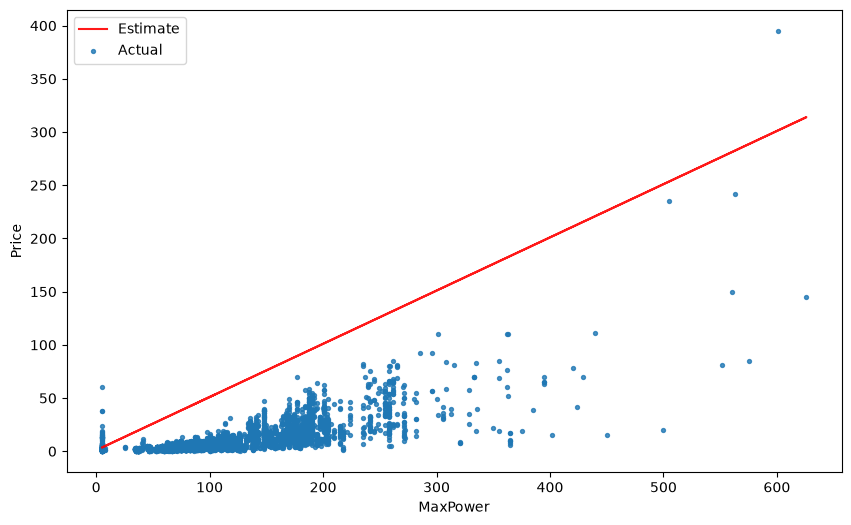

In [33]:
try_parameters(0.5, 1)

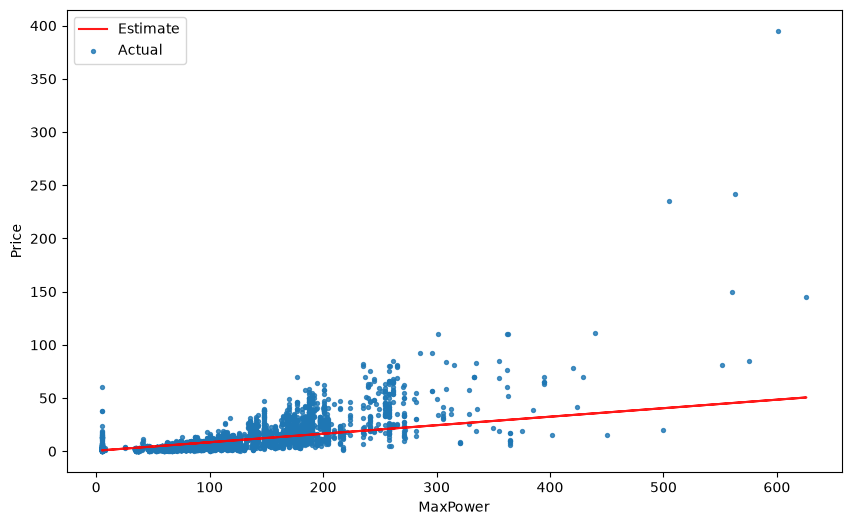

In [35]:
try_parameters(0.08, 0.5)

### **Univariate Linear Regression using Scikit-learn**

In [36]:
!gdown 1UpLnYA48Vy_lGUMMLG-uQE1gf_Je12Lh

Using cookies from /Users/siddharth/.cache/gdown/cookies.txt
Downloading...
From: https://drive.google.com/uc?id=1UpLnYA48Vy_lGUMMLG-uQE1gf_Je12Lh
To: /Users/siddharth/Documents/Siddharth/MyNotes/MyNotes/AI_ML/Jupyter_Notebooks/cars24-car-price-clean.csv
100%|█████████████████████████████████████| 7.10M/7.10M [00:01<00:00, 6.89MB/s]


#### Explanation of !gdown

`!gdown` is a shell command used primarily in Jupyter Notebooks and Google Colab to download public files or folders directly from **Google Drive** using their URL or unique File ID.

The leading exclamation mark (`!`) instructs the notebook to execute `gdown` as a command-line bash utility rather than as Python code.

---

##### Why It Is Used

Standard command-line tools like `wget` or `curl` often fail on large Google Drive files because Google presents a "virus scan warning" confirmation screen for files over 100 MB. `gdown` automatically handles those confirmation cookies and permission handshakes to download large datasets seamlessly.

---

##### Common Syntax & Usage

* **Download using a full share URL:**
```bash
!gdown https://drive.google.com/uc?id=YOUR_FILE_ID

```


* **Download using only the File ID:**
```bash
!gdown --id YOUR_FILE_ID

```


* **Download and rename the output file:**
```bash
!gdown https://drive.google.com/uc?id=YOUR_FILE_ID -O dataset.zip

```


* **Download an entire shared folder:**
```bash
!gdown --folder https://drive.google.com/drive/folders/YOUR_FOLDER_ID

```



---

##### Requirements

* **Access Permissions:** The Google Drive link must have its sharing settings configured to **"Anyone with the link can view."**
* **Installation:** In environments where it is not pre-installed (unlike Google Colab, where it comes built-in), install it first via pip:
```bash
!pip install gdown

```

In [37]:
df = pd.read_csv('cars24-car-price-clean.csv')
df.head()

,selling_price,year,km_driven,mileage,engine,max_power,age,make,model,Individual,Trustmark Dealer,Diesel,Electric,LPG,Petrol,Manual,5,>5
0,-1.111046,-0.801317,1.195828,0.045745,-1.310754,-1.157780,0.801317,-0.433854,-1.125683,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
1,-0.223944,0.450030,-0.737872,-0.140402,-0.537456,-0.360203,-0.450030,-0.327501,-0.333227,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
2,-0.915058,-1.426990,0.035608,-0.582501,-0.537456,-0.404885,1.426990,-0.327501,-0.789807,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
3,-0.892365,-0.801317,-0.409143,0.329620,-0.921213,-0.693085,0.801317,-0.433854,-0.905265,1.248892,-0.098382,-0.985275,-0.020095,-0.056917,1.024622,0.495818,0.444503,-0.424728
4,-0.182683,0.137194,-0.544502,0.760085,0.042999,0.010435,-0.137194,-0.246579,-0.013096,-0.800710,-0.098382,1.014945,-0.020095,-0.056917,-0.975970,0.495818,0.444503,-0.424728


**Difference between earlier data and this data is that present data is clean(normalize)**

In [43]:
x = df['max_power'].values
y = df['selling_price'].values

x = x.reshape(x.size,1)
y = y.reshape(y.size,1)


In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

type(model)

sklearn.linear_model._base.LinearRegression

In [45]:
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.77]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[140.78]


In [46]:
y_hat = model.predict(x)

In [47]:
print('Predicted')
print(y_hat[:5])

print('Actual')
print(y[:5])

Predicted
[[-0.89194167]
 [-0.27749684]
 [-0.31191952]
 [-0.5339458 ]
 [ 0.00803929]]
Actual
[[-1.11104589]
 [-0.22394353]
 [-0.91505816]
 [-0.89236484]
 [-0.18268296]]


In [48]:
weight = model.coef_
bias = model.intercept_

print('Weight:', weight)
print('Bias:', bias)

Weight: [[0.77038985]]
Bias: [-1.65432737e-16]


**Now since we know our optimal weight and bias we can use it for any new datapoint**

selling_price = 0.77038985*max_power+-1.65432737e-16

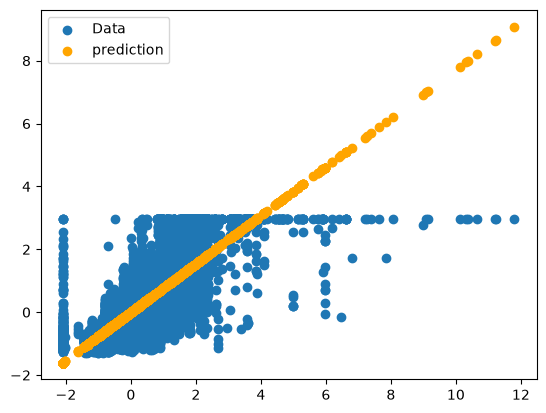

In [50]:
fig = plt.figure()
plt.scatter(x,y, label='Data')
plt.scatter(x,y_hat,color='orange',label='prediction')
plt.legend()
plt.show()
